# Vision-Based Ciliary Beat Frequency Analysis

This notebook implements a vision-based pipeline to estimate ciliary beat frequency (CBF) from microscopy videos.

The workflow includes:
1. Video preprocessing
2. Motion signal extraction
3. Frequency analysis
4. Feature generation
5. Machine learning classification

In [1]:
#Important Libraries and methods for the project
import os
import warnings
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt
from scipy.fft import rfft, rfftfreq
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Check if optional packages are available
try:
    import tensorflow as tf
    TENSORFLOW_AVAILABLE = True
except ImportError:
    TENSORFLOW_AVAILABLE = False

try:
    import xgboost
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print('TensorFlow available:', TENSORFLOW_AVAILABLE)
print('XGBoost available:', XGBOOST_AVAILABLE)

TensorFlow available: True
XGBoost available: True


In [2]:
def video_to_array(video_path, max_frames=None):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_path}")

    fps = float(cap.get(cv2.CAP_PROP_FPS))

    frames = []
    count = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(gray.astype(np.float32))
        count += 1
        if max_frames is not None and count >= max_frames:
            break

    cap.release()

    if len(frames) == 0:
        raise RuntimeError(f"No frames read from: {video_path}")

    video_np_array = np.stack(frames, axis=0)  # (T, H, W)
    return video_np_array, fps

In [3]:
def split_video(video_matrix, n_split_axis):
    T, H, W = video_matrix.shape
    step_h = int(np.ceil(H / n_split_axis))
    step_w = int(np.ceil(W / n_split_axis))

    rois = []
    meta = []  # (roi_id, x, y, w, h)
    roi_id = 0

    for gy in range(n_split_axis):
        y0 = gy * step_h
        y1 = min((gy + 1) * step_h, H)
        for gx in range(n_split_axis):
            x0 = gx * step_w
            x1 = min((gx + 1) * step_w, W)
            roi = video_matrix[:, y0:y1, x0:x1]
            if roi.size == 0:
                continue
            rois.append(roi)
            meta.append((roi_id, x0, y0, x1 - x0, y1 - y0))
            roi_id += 1

    return rois, meta

In [4]:
def roi_mean_intensity(roi_cube):
    return roi_cube.mean(axis=(1, 2))

In [5]:
def center_signal(x):
    x = np.asarray(x, dtype=float)
    return x - np.mean(x)

In [6]:
def bandpass_filter(x, fs, low=2.0, high=30.0, order=2):
    nyq = 0.5 * fs
    low_cut = max(low / nyq, 1e-6)
    high_cut = min(high / nyq, 0.99)
    if low_cut >= high_cut:
        return x
    b, a = butter(order, [low_cut, high_cut], btype="band")
    return filtfilt(b, a, x)

In [7]:
def fft_peak(signal_1d, fs, fmin=2.0, fmax=30.0):
    s = np.asarray(signal_1d, dtype=float)
    if s.size < 8:
        return np.nan, np.nan, s

    s = center_signal(s)
    s_filt = bandpass_filter(s, fs, fmin, fmax, order=2)

    spec = rfft(s_filt)
    freqs = rfftfreq(len(s_filt), d=1.0 / fs)
    mags = np.abs(spec)

    mask = (freqs >= fmin) & (freqs <= fmax)
    if not np.any(mask):
        return np.nan, np.nan, s_filt

    idx = np.argmax(mags[mask])
    best_freq = float(freqs[mask][idx])
    best_mag = float(mags[mask][idx])

    return best_freq, best_mag, s_filt

In [8]:
def skeletonize_binary(binary_img):
    """
    Skeletonize using skimage if available, otherwise OpenCV thinning if available,
    otherwise return the binary image (still saves something).
    """
    b = (binary_img > 0).astype(np.uint8) * 255

    # option 1: skimage
    try:
        from skimage.morphology import skeletonize
        sk = skeletonize((b > 0))
        return (sk.astype(np.uint8) * 255)
    except Exception:
        pass

In [9]:
from fileinput import filename
from os import name


def save_skeleton_demo(frame_gray, out_path):
    """
    Takes ONE grayscale frame, makes a binary + skeleton image,
    saves the skeleton image, and returns both images.
    """
    g = frame_gray.astype(np.uint8)

    # Gaussian blur to reduce tiny noise
    g = cv2.GaussianBlur(g, (5, 5), 0)

    # threshold
    bin_img = cv2.adaptiveThreshold(
        g, 255,
        adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        thresholdType=cv2.THRESH_BINARY_INV,
        blockSize=31,
        C=5
    )

    # clean specks
    kernel = np.ones((3, 3), np.uint8)
    bin_img = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, kernel, iterations=1)

    skel = skeletonize_binary(bin_img)
    cv2.imwrite(out_path, skel)
    return bin_img, skel  

def label_from_filename(filename):
    name = str(filename).lower()
    if "healthy" in name:
        return "Healthy"
    return "PCD"


In [10]:
def process_videos_folder(videodir, outdir, extensions=None, ngrid=10, maxframes=300, fmin=2.0, fmax=30.0):
    if extensions is None:
        extensions = ['.avi', '.mov', '.mp4', '.mkv']

    if not os.path.isdir(videodir):
        raise RuntimeError(f"Video directory not found: {videodir}")

    os.makedirs(outdir, exist_ok=True)
    ext_set = {e.lower() for e in extensions}

    # Recursively collect all video file paths from videodir and subdirectories
    files = []
    for root, dirs, filenames in os.walk(videodir):
        for f in filenames:
            if os.path.splitext(f)[1].lower() in ext_set:
                files.append(os.path.join(root, f))

    if len(files) == 0:
        print(f"No videos found in: {videodir}")
        empty_df = pd.DataFrame(columns=['video', 'label', 'cbf_hz', 'peak_mag', 'var', 'zcr'])
        empty_df.to_csv(os.path.join(outdir, "cbf_per_video.csv"), index=False)
        return empty_df

    roi_rows = []

    for fpath in files:
        fname = os.path.basename(fpath)
        print(f"Processing: {fpath}")

        try:
            video_np_array, fps = video_to_array(fpath, max_frames=maxframes)

            # save one skeleton demo frame per video
            skel_out = os.path.join(outdir, f"{os.path.splitext(fname)[0]}_skeleton.png")
            save_skeleton_demo(video_np_array[0], skel_out)

            rois, meta = split_video(video_np_array, ngrid)
            label = label_from_filename(fname)

            for roi, m in zip(rois, meta):
                roi_id = m[0]
                x = roi_mean_intensity(roi)
                cbf_hz, peak_mag, x_filt = fft_peak(x, fs=fps, fmin=fmin, fmax=fmax)

                var_val = float(np.var(x_filt)) if np.size(x_filt) else np.nan
                z = np.asarray(x_filt, dtype=float)
                zcr_val = float(np.mean(np.abs(np.diff(np.sign(z))) > 0)) if z.size > 1 else np.nan

                roi_rows.append({
                    'video': fname,
                    'roi_id': roi_id,
                    'label': label,
                    'cbf_hz': cbf_hz,
                    'peak_mag': peak_mag,
                    'var': var_val,
                    'zcr': zcr_val
                })

        except Exception as e:
            print(f"Skipped {fname}: {e}")

    roi_df = pd.DataFrame(roi_rows)
    if roi_df.empty:
        roi_df = pd.DataFrame(columns=['video', 'roi_id', 'label', 'cbf_hz', 'peak_mag', 'var', 'zcr'])

    roi_csv = os.path.join(outdir, "cbf_per_roi.csv")
    roi_df.to_csv(roi_csv, index=False)


    video_df = (
        roi_df.groupby(['video', 'label'], as_index=False)
        .agg(
            cbf_hz=('cbf_hz', 'median'),
            cbf_std=('cbf_hz', 'std'),
            peak_mag=('peak_mag', 'median'),
            var=('var', 'median'),
            zcr=('zcr', 'median'),
            n_valid_rois=('cbf_hz', 'count')
        )
    )

    video_df['cbf_std'] = video_df['cbf_std'].fillna(0)

    video_csv = os.path.join(outdir, "cbf_per_video.csv")
    video_df.to_csv(video_csv, index=False)

    print(f"Saved ROI-level features to: {roi_csv}")
    print(f"Saved video-level features to: {video_csv}")
    return video_df


if __name__ == "__main__":

    videodir = r"C:\Users\Ssehra\Desktop\PCD\Data_videos"
    outdir   = r"C:\Users\Ssehra\Desktop\PCD\output\CIliary Beat Frequency"

    import os
    print("Using videos from:", videodir, "| exists?", os.path.isdir(videodir))
    print("Saving outputs to:", outdir)

    process_videos_folder(
        videodir=videodir,
        outdir=outdir,
        extensions=['.avi', '.mov', '.mp4', '.mkv', '.MOV', '.AVI'],
        ngrid=10,
        maxframes=300,
        fmin=2.0,
        fmax=30.0
    )


Using videos from: C:\Users\Ssehra\Desktop\PCD\Data_videos | exists? True
Saving outputs to: C:\Users\Ssehra\Desktop\PCD\output\CIliary Beat Frequency
Processing: C:\Users\Ssehra\Desktop\PCD\Data_videos\ATP_treatment\m1p3_atp0_1.avi
Processing: C:\Users\Ssehra\Desktop\PCD\Data_videos\ATP_treatment\m1p3_atp0_2.avi
Processing: C:\Users\Ssehra\Desktop\PCD\Data_videos\ATP_treatment\m1p3_atp0_3.avi
Processing: C:\Users\Ssehra\Desktop\PCD\Data_videos\ATP_treatment\m1p3_atp1000_1.avi
Processing: C:\Users\Ssehra\Desktop\PCD\Data_videos\ATP_treatment\m1p3_atp1000_2.avi
Processing: C:\Users\Ssehra\Desktop\PCD\Data_videos\ATP_treatment\m1p3_atp1000_3.avi
Processing: C:\Users\Ssehra\Desktop\PCD\Data_videos\ATP_treatment\m1p3_atp100_1.avi
Processing: C:\Users\Ssehra\Desktop\PCD\Data_videos\ATP_treatment\m1p3_atp100_2.avi
Processing: C:\Users\Ssehra\Desktop\PCD\Data_videos\ATP_treatment\m1p3_atp100_3.avi
Processing: C:\Users\Ssehra\Desktop\PCD\Data_videos\ATP_treatment\m1p3_atp100_4.avi
Processing: 

In [11]:
# def process_videos_folder(videodir, outdir, extensions=None, ngrid=10, maxframes=300, fmin=2.0, fmax=30.0):
#     if extensions is None:
#         extensions = ['.avi', '.mov', '.mp4', '.mkv']

#     if not os.path.isdir(videodir):
#         raise RuntimeError(f"Video directory not found: {videodir}")

#     os.makedirs(outdir, exist_ok=True)
#     ext_set = {e.lower() for e in extensions}

#     files = [
#         f for f in os.listdir(videodir)
#         if os.path.isfile(os.path.join(videodir, f)) and os.path.splitext(f)[1].lower() in ext_set
#     ]

#     if len(files) == 0:
#         print(f"No videos found in: {videodir}")
#         empty_df = pd.DataFrame(columns=['video', 'label', 'cbf_hz', 'peak_mag', 'var', 'zcr'])
#         empty_df.to_csv(os.path.join(outdir, "cbf_per_video.csv"), index=False)
#         return empty_df

#     roi_rows = []

#     for fname in files:
#         fpath = os.path.join(videodir, fname)
#         print(f"Processing: {fname}")

#         try:
#             video_np_array, fps = video_to_array(fpath, max_frames=maxframes)

#             # save one skeleton demo frame per video
#             skel_out = os.path.join(outdir, f"{os.path.splitext(fname)[0]}_skeleton.png")
#             save_skeleton_demo(video_np_array[0], skel_out)

#             rois, meta = split_video(video_np_array, ngrid)
#             label = label_from_filename(fname)

#             for roi, m in zip(rois, meta):
#                 roi_id = m[0]
#                 x = roi_mean_intensity(roi)
#                 cbf_hz, peak_mag, x_filt = fft_peak(x, fs=fps, fmin=fmin, fmax=fmax)

#                 var_val = float(np.var(x_filt)) if np.size(x_filt) else np.nan
#                 z = np.asarray(x_filt, dtype=float)
#                 zcr_val = float(np.mean(np.abs(np.diff(np.sign(z))) > 0)) if z.size > 1 else np.nan

#                 roi_rows.append({
#                     'video': fname,
#                     'roi_id': roi_id,
#                     'label': label,
#                     'cbf_hz': cbf_hz,
#                     'peak_mag': peak_mag,
#                     'var': var_val,
#                     'zcr': zcr_val
#                 })

#         except Exception as e:
#             print(f"Skipped {fname}: {e}")

#     roi_df = pd.DataFrame(roi_rows)
#     if roi_df.empty:
#         roi_df = pd.DataFrame(columns=['video', 'roi_id', 'label', 'cbf_hz', 'peak_mag', 'var', 'zcr'])

#     roi_csv = os.path.join(outdir, "cbf_per_roi.csv")
#     roi_df.to_csv(roi_csv, index=False)

#     video_df = (
#     roi_df.groupby(['video','label'], as_index=False)[
#         ['cbf_hz','peak_mag','var','zcr']
#     ].max()
# )

#     video_csv = os.path.join(outdir, "cbf_per_video.csv")
#     video_df.to_csv(video_csv, index=False)

#     print(f"Saved ROI-level features to: {roi_csv}")
#     print(f"Saved video-level features to: {video_csv}")
#     return video_df


# if __name__ == "__main__":

#     videodir = r"C:\Users\Ssehra\Desktop\PCD\Data_videos"
#     outdir   = r"C:\Users\Ssehra\Desktop\PCD\output\CIliary Beat Frequency"

#     import os
#     print("Using videos from:", videodir, "| exists?", os.path.isdir(videodir))
#     print("Saving outputs to:", outdir)

#     process_videos_folder(
#         videodir=videodir,
#         outdir=outdir,
#         extensions=['.avi', '.mov', '.mp4', '.mkv', '.MOV', '.AVI'],
#         ngrid=10,
#         maxframes=300,
#         fmin=2.0,
#         fmax=30.0
#     )

Machine Learing Pipeline

The CBF cutoff values are given from this paper:  https://www.mdpi.com/2075-4418/16/5/704

In [12]:
# Plotting Quantitative analysis of CBF resullts to classify between healthy and PCD samples. 
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statistics import mean
from scipy.stats import skew, kurtosis
from scipy.signal import correlate
from scipy.stats import entropy as scipy_entropy
from scipy.stats import ttest_ind 
import scipy.stats as stats

In [13]:
# Show several frames from the sample video to confirm it loaded correctly
if "video_files" not in globals():
    video_files = [
        f for f in os.listdir(videodir)
        if os.path.isfile(os.path.join(videodir, f)) and os.path.splitext(f)[1].lower() in ['.avi', '.mov', '.mp4', '.mkv']
    ]

if "sample_video_path" not in globals():
    sample_video_path = os.path.join(videodir, video_files[0]) if len(video_files) > 0 else None

if sample_video_path is None:
    print("No sample video available. Check 'videodir' and 'video_files'.")
else:
    if "sample_video" not in globals():
        sample_video, sample_fps = video_to_array(sample_video_path, max_frames=120)

    n_show = min(6, sample_video.shape[0])
    idxs = np.linspace(0, sample_video.shape[0] - 1, n_show, dtype=int)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.ravel()

    for ax, idx in zip(axes, idxs):
        ax.imshow(sample_video[idx], cmap='gray')
        ax.set_title(f"Frame {idx}")
        ax.axis('off')

    for ax in axes[len(idxs):]:
        ax.axis('off')

    plt.suptitle(f"Sample video preview: {os.path.basename(sample_video_path)}")
    plt.tight_layout()
    plt.show()

No sample video available. Check 'videodir' and 'video_files'.


In [14]:
#show multiple thresholds and cskelenton images
if sample_video_path is not None:
    n_show = min(6, sample_video.shape[0])
    idxs = np.linspace(0, sample_video.shape[0] - 1, n_show, dtype=int)

    fig, axes = plt.subplots(n_show, 3, figsize=(12, 3.2 * n_show))

    if n_show == 1:
        axes = np.array([axes])

    for row, idx in enumerate(idxs):
        frame_gray = sample_video[idx].astype(np.uint8)
        binary_img, skeleton_img = save_skeleton_demo(
            frame_gray,
            os.path.join(outdir, f"skeleton_demo_frame_{idx}.png")  
        )

        axes[row, 0].imshow(frame_gray, cmap='gray')
        axes[row, 0].set_title(f'raw frame {idx}')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(binary_img, cmap='gray')
        axes[row, 1].set_title(f'thresholded frame {idx}')
        axes[row, 1].axis('off')

        axes[row, 2].imshow(skeleton_img, cmap='gray')
        axes[row, 2].set_title(f'skeletonized frame {idx}')
        axes[row, 2].axis('off')

    plt.tight_layout()
    plt.show()


In [16]:
#Show ROi Grid on sample video:
if sample_video_path is not None:
    if "sample_video" not in globals():
        sample_video, sample_fps = video_to_array(sample_video_path, max_frames=120)

    ngrid_demo = 6
    frame_u8 = sample_video[0].astype(np.uint8)
    display_img = cv2.cvtColor(frame_u8, cv2.COLOR_GRAY2BGR)

    _, H, W = sample_video.shape
    step_h = int(np.ceil(H / ngrid_demo))
    step_w = int(np.ceil(W / ngrid_demo))

    for gy in range(ngrid_demo):
        for gx in range(ngrid_demo):
            y0 = gy * step_h
            y1 = min((gy + 1) * step_h, H)
            x0 = gx * step_w
            x1 = min((gx + 1) * step_w, W)
            cv2.rectangle(display_img, (x0, y0), (x1 - 1, y1 - 1), (255, 255, 255), 1)

    plt.figure(figsize=(7, 7))
    plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
    plt.title('HERE ADDED: ROI grid overlay')
    plt.axis('off')
    plt.show()
else:
    print("No sample video available. Run the sample video loading cell first.")


No sample video available. Run the sample video loading cell first.


In [17]:
#Plot Multiple ROi's and their FFT analysis

if sample_video_path is not None:
    sample_rois, sample_meta = split_video(sample_video, n_split_axis=6)  
    roi_ids_to_show = [0, min(5, len(sample_rois)-1), min(10, len(sample_rois)-1), min(15, len(sample_rois)-1)]
    roi_ids_to_show = sorted(set([rid for rid in roi_ids_to_show if rid >= 0]))

    fig, axes = plt.subplots(len(roi_ids_to_show), 2, figsize=(12, 3.5 * len(roi_ids_to_show)))
    if len(roi_ids_to_show) == 1:
        axes = np.array([axes])

    for row, rid in enumerate(roi_ids_to_show):
        roi_cube = sample_rois[rid]
        raw_signal = roi_mean_intensity(roi_cube)
        peak_freq, peak_mag, filt_signal = fft_peak(raw_signal, sample_fps, fmin=2.0, fmax=30.0)

        spec = rfft(filt_signal)
        freqs = rfftfreq(len(filt_signal), d=1.0 / sample_fps)
        mags = np.abs(spec)
        mask = (freqs >= 0) & (freqs <= 40)

        axes[row, 0].plot(raw_signal, label='raw')
        axes[row, 0].plot(filt_signal, label='filtered')
        axes[row, 0].set_title(f'ROI {rid} signal')
        axes[row, 0].set_xlabel('Frame')
        axes[row, 0].set_ylabel('Mean intensity')
        axes[row, 0].legend()
        axes[row, 0].grid(True, linestyle='--', alpha=0.4)

        axes[row, 1].plot(freqs[mask], mags[mask])
        if not np.isnan(peak_freq):
            axes[row, 1].axvline(peak_freq, linestyle='--', label=f'peak={peak_freq:.2f} Hz')
            axes[row, 1].legend()
        axes[row, 1].set_title(f'ROI {rid} FFT')
        axes[row, 1].set_xlabel('Frequency (Hz)')
        axes[row, 1].set_ylabel('Magnitude')
        axes[row, 1].grid(True, linestyle='--', alpha=0.4)
        
    plt.tight_layout()
    plt.show()


In [18]:
#PREVIEW EXTRACTED VALUES
if os.path.exists(os.path.join(outdir, "cbf_per_video.csv")):
    df_preview = pd.read_csv(os.path.join(outdir, "cbf_per_video.csv"))
    print("Preview of extracted video-level features:")
    print(df_preview.head())

if os.path.exists(os.path.join(outdir, "cbf_per_roi.csv")):
    df_roi_preview = pd.read_csv(os.path.join(outdir, "cbf_per_roi.csv"))
    print("Preview of extracted ROI-level features:")
    print(df_roi_preview.head())

Preview of extracted video-level features:
        video label    cbf_hz   cbf_std   peak_mag       var       zcr  n_valid_rois
0   PCD_1.mp4   PCD  3.333333  1.421060   5.350823  0.006568  0.411371           100
1  PCD_10.mp4   PCD  8.300000  2.278918   4.778505  0.004448  0.438127           100
2  PCD_11.mov   PCD  9.000000  1.261706  13.804965  0.016182  0.491639           100
3  PCD_12.mov   PCD  2.800000  0.790905  64.494648  0.426605  0.237458           100
4  PCD_13.mov   PCD  2.785714  5.036509   3.880153  0.010372  0.395683           100
Preview of extracted ROI-level features:
             video  roi_id label  cbf_hz  peak_mag       var       zcr
0  m1p3_atp0_1.avi       0   PCD   10.92  0.918434  0.000462  0.602410
1  m1p3_atp0_1.avi       1   PCD   10.92  0.833288  0.000453  0.546185
2  m1p3_atp0_1.avi       2   PCD   10.44  0.796065  0.000431  0.522088
3  m1p3_atp0_1.avi       3   PCD   10.92  0.852726  0.000386  0.497992
4  m1p3_atp0_1.avi       4   PCD   10.92  0.805217 

In [19]:
#Add descriptive statistics and t-tests comparing PCD vs Healthy for the extracted CBF values
if os.path.exists(os.path.join(outdir, "cbf_per_video.csv")):
    df = pd.read_csv(os.path.join(outdir, "cbf_per_video.csv"))
    print("\nDescriptive statistics for video-level CBF:")
    print(df.groupby('label')['cbf_hz'].describe())

    pcd_cbf = df[df['label'] == 'PCD']['cbf_hz'].dropna()
    healthy_cbf = df[df['label'] == 'Healthy']['cbf_hz'].dropna()

    if len(pcd_cbf) > 1 and len(healthy_cbf) > 1:
        t_stat, p_value = stats.ttest_ind(pcd_cbf, healthy_cbf, equal_var=False, nan_policy='omit')
        print(f"\nWelch's t-test (PCD vs Healthy CBF): t={t_stat:.3f}, p={p_value:.3e}")
    else:
        print("\nNot enough data for t-test (need at least 2 samples in each group).")


Descriptive statistics for video-level CBF:
         count      mean       std       min    25%    50%   75%        max
label                                                                      
Healthy   12.0  4.796008  6.765164  2.000000  2.625  2.825  3.10  26.200000
PCD      379.0  5.288666  2.132917  2.040816  3.840  5.040  6.36  26.268657

Welch's t-test (PCD vs Healthy CBF): t=0.252, p=8.058e-01


Machine Learning Pipeline 

In [20]:
# Plotting Quantitative analysis of CBF resullts to classify between healthy and PCD samples. 
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statistics import mean
from scipy.stats import skew, kurtosis
from scipy.signal import correlate
from scipy.stats import entropy as scipy_entropy
from scipy.stats import ttest_rel
import scipy.stats as stats

In [21]:
#hi load only your extracted video dataset
video_df = pd.read_csv(r"C:\Users\Ssehra\Desktop\PCD\output\CIliary Beat Frequency\cbf_per_video.csv")

#hi create binary labels from your own video labels
video_df['label_bin'] = video_df['label'].str.lower().map({
    'healthy': 0,
    'pcd': 1
})

#hi keep only video-derived features
feature_cols = ['cbf_hz', 'cbf_std', 'peak_mag', 'var', 'zcr', 'n_valid_rois']
video_df = video_df[feature_cols + ['label_bin', 'video', 'label']].copy()

print("Total CBF video samples:", video_df.shape)
print(video_df.head())

Total CBF video samples: (391, 9)
     cbf_hz   cbf_std   peak_mag       var       zcr  n_valid_rois  label_bin       video label
0  3.333333  1.421060   5.350823  0.006568  0.411371           100          1   PCD_1.mp4   PCD
1  8.300000  2.278918   4.778505  0.004448  0.438127           100          1  PCD_10.mp4   PCD
2  9.000000  1.261706  13.804965  0.016182  0.491639           100          1  PCD_11.mov   PCD
3  2.800000  0.790905  64.494648  0.426605  0.237458           100          1  PCD_12.mov   PCD
4  2.785714  5.036509   3.880153  0.010372  0.395683           100          1  PCD_13.mov   PCD


In [23]:

#hi reload clean CBF video dataset
import pandas as pd

video_df = pd.read_csv(r"C:\Users\Ssehra\Desktop\PCD\output\CIliary Beat Frequency\cbf_per_video.csv")

video_df["label_bin"] = video_df["label"].str.lower().map({
    "healthy": 0,
    "pcd": 1
})

feature_cols = ['cbf_hz', 'cbf_std', 'peak_mag', 'var', 'zcr', 'n_valid_rois']

for col in feature_cols + ['label_bin']:
    video_df[col] = pd.to_numeric(video_df[col], errors='coerce')

video_df = video_df.dropna(subset=feature_cols + ['label_bin']).copy()
video_df['label_bin'] = video_df['label_bin'].astype(int)

X = video_df[feature_cols]
y = video_df['label_bin']

print("Prepared CBF dataset:", X.shape, y.shape)
print(video_df.head())

Prepared CBF dataset: (391, 6) (391,)
        video label    cbf_hz   cbf_std   peak_mag       var       zcr  n_valid_rois  label_bin
0   PCD_1.mp4   PCD  3.333333  1.421060   5.350823  0.006568  0.411371           100          1
1  PCD_10.mp4   PCD  8.300000  2.278918   4.778505  0.004448  0.438127           100          1
2  PCD_11.mov   PCD  9.000000  1.261706  13.804965  0.016182  0.491639           100          1
3  PCD_12.mov   PCD  2.800000  0.790905  64.494648  0.426605  0.237458           100          1
4  PCD_13.mov   PCD  2.785714  5.036509   3.880153  0.010372  0.395683           100          1


In [24]:

from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=5
    ))
])

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

scores = cross_val_score(
    pipe,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("CBF repeated CV scores:", scores)
print("CBF mean accuracy: {:.2f}% ± {:.2f}%".format(scores.mean() * 100, scores.std() * 100))

CBF repeated CV scores: [0.96202532 0.94871795 0.97435897 0.97435897 0.96153846 0.96202532
 0.97435897 0.97435897 0.97435897 0.96153846 0.96202532 0.96153846
 0.98717949 0.98717949 0.96153846 0.96202532 0.97435897 0.96153846
 0.97435897 0.96153846 0.96202532 0.98717949 0.97435897 0.97435897
 0.96153846 0.96202532 0.97435897 0.97435897 0.96153846 0.96153846
 0.96202532 0.97435897 0.97435897 0.97435897 0.96153846 0.96202532
 0.97435897 0.97435897 0.98717949 0.96153846 0.96202532 0.97435897
 0.97435897 0.97435897 0.96153846 0.96202532 0.97435897 0.97435897
 0.98717949 0.96153846]
CBF mean accuracy: 96.93% ± 0.88%


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Fitting 3 folds for each of 12 candidates, totalling 36 fits


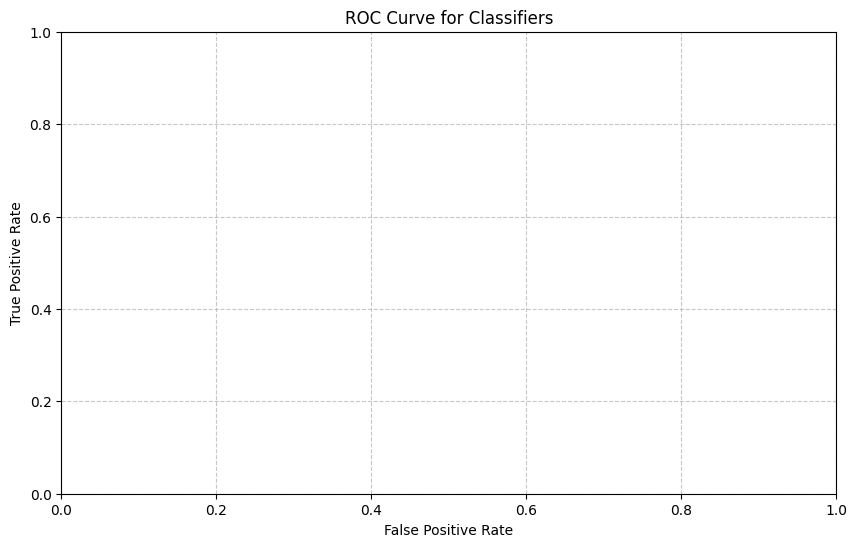

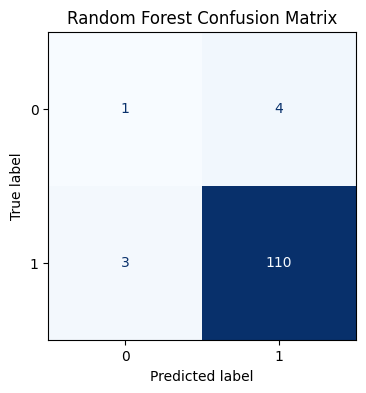

Fitting 3 folds for each of 24 candidates, totalling 72 fits


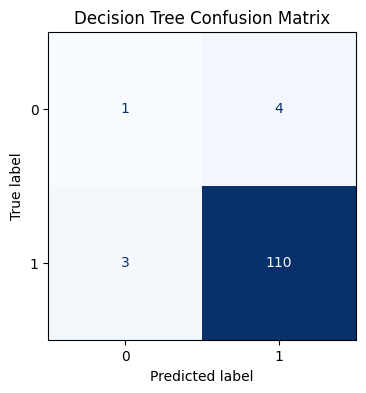

Fitting 3 folds for each of 108 candidates, totalling 324 fits


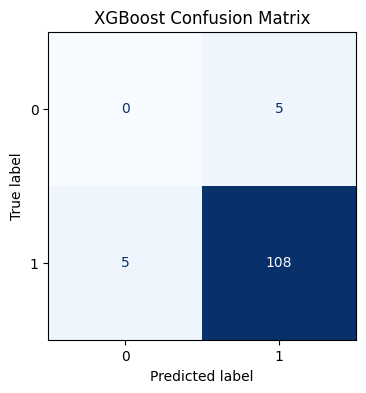

Fitting 3 folds for each of 6 candidates, totalling 18 fits


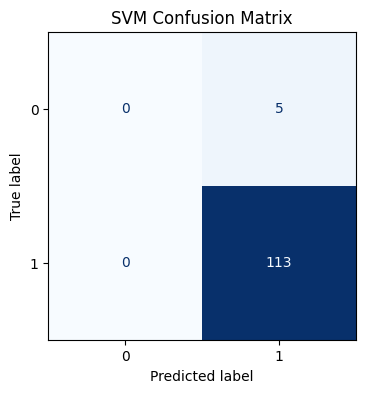

Reloading Tuner from cnn_tuning_dir\cnn_tuning\tuner0.json
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.0138 - loss: 1.2042 - val_accuracy: 0.9636 - val_loss: 0.6170
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9771 - loss: 0.4016 - val_accuracy: 0.9636 - val_loss: 0.2170
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9771 - loss: 0.1637 - val_accuracy: 0.9636 - val_loss: 0.1316
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9771 - loss: 0.1130 - val_accuracy: 0.9636 - val_loss: 0.1151
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9771 - loss: 0.1026 - val_accuracy: 0.9636 - val_loss: 0.1129
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9771 - loss: 0.0988 - val_accuracy: 0.9636 - val_loss: 0.1133
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9771 - loss: 0.0982 - val_accuracy: 0.9636 - val_loss: 0.1137
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.97

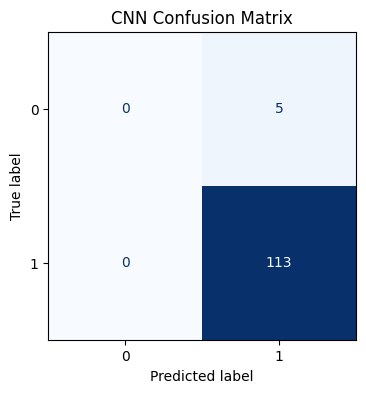

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Reloading Tuner from rnn_tuning_dir\rnn_tuning\tuner0.json
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step - accuracy: 0.8394 - loss: 0.4355 - val_accuracy: 0.9636 - val_loss: 0.1846
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9771 - loss: 0.1206 - val_accuracy: 0.9636 - val_loss: 0.1387
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9771 - loss: 0.1058 - val_accuracy: 0.9636 - val_loss: 0.1646
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9771 - loss: 0.1044 - val_accuracy: 0.9636 - val_loss: 0.1512
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9771 - loss: 0.0940 - val_accuracy: 0.9636 - val_loss: 0.1336
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9771 - loss: 0.0874 - val_accuracy: 0.9636 - val_loss: 0.1202
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9771 - loss: 0.0868 - val_accuracy: 0.9636 - val_loss: 0.1175
Epoch 8/10
7/7 ━━━━━━━━━━━━

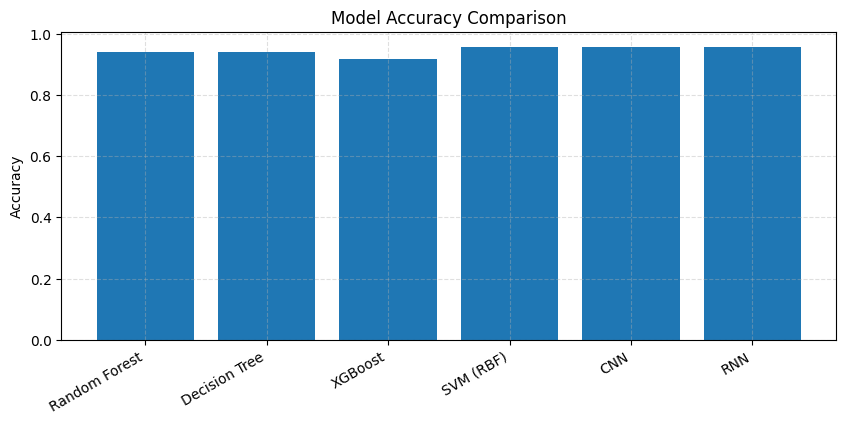

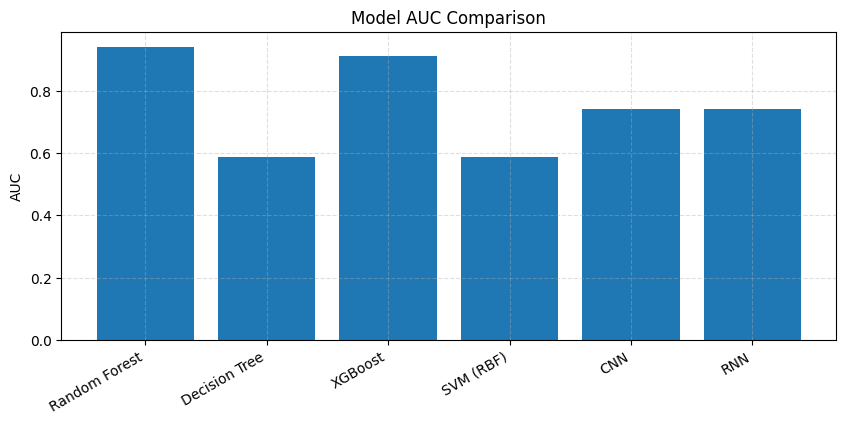

In [ ]:
%pip install tensorflow keras-tuner
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.svm import SVC  # SVM classifier
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, Flatten, Input
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt
import warnings
warnings.filterwarnings("ignore")

# --- Utility function to compute sensitivity and specificity ---
def compute_sensitivity_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return sensitivity, specificity

# Define the path to your data file
data_path = r"C:\Users\Ssehra\Desktop\PCD\output\CIliary Beat Frequency\cbf_per_video.csv"

df = pd.read_csv(data_path)

df = df.rename(columns={"cbf_hz": "CBF"})
df = df[["video","label","CBF"]]

df["label"] = df["label"].astype(str).str.lower().map({"pcd":1,"healthy":0})

df = df.dropna(subset=["CBF","label"]).reset_index(drop=True)

x = df[["CBF"]].to_numpy()
y = df["label"].astype(int).to_numpy()

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# --- Function to plot ROC curve and compute AUC for a given model ---
def plot_roc_auc(model, x_test, y_test, model_name, ax):
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_test)[:, 1]
    else:
        y_prob = model.predict(x_test).ravel()

    
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.2f})")
    return roc_auc, y_prob

# --- Plot setup ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("ROC Curve for Classifiers")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.grid(True, linestyle='--', alpha=0.7)

results = {}

#confusion matrix plotting function                                                                            b 
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confmat(y_test, y_pred, title):
    fig_cm, ax_cm = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=ax_cm, cmap="Blues", colorbar=False
    )
    ax_cm.set_title(title)
    plt.show()


# 1. Random Forest Classifier (GridSearchCV)
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf_model = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf_model, rf_param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
rf_grid.fit(x_train_scaled, y_train)
best_rf_model = rf_grid.best_estimator_
rf_pred = best_rf_model.predict(x_test_scaled)
plot_confmat(y_test, rf_pred, "Random Forest Confusion Matrix")
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_auc, _ = plot_roc_auc(best_rf_model, x_test_scaled, y_test, "Random Forest (Tuned)", ax)
rf_sens, rf_spec = compute_sensitivity_specificity(y_test, rf_pred)
results["Random Forest"] = {
    "Accuracy": rf_accuracy,
    "AUC": rf_auc,
    "Sensitivity": rf_sens,
    "Specificity": rf_spec
}


# 2. Decision Tree Classifier (GridSearchCV)
dt_param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
dt_model = DecisionTreeClassifier(random_state=42)
dt_grid = GridSearchCV(dt_model, dt_param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
dt_grid.fit(x_train_scaled, y_train)
best_dt_model = dt_grid.best_estimator_
dt_pred = best_dt_model.predict(x_test_scaled)
plot_confmat(y_test, dt_pred, "Decision Tree Confusion Matrix")
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_auc, _ = plot_roc_auc(best_dt_model, x_test_scaled, y_test, "Decision Tree (Tuned)", ax)
dt_sens, dt_spec = compute_sensitivity_specificity(y_test, dt_pred)
results["Decision Tree"] = {
    "Accuracy": dt_accuracy,
    "AUC": dt_auc,
    "Sensitivity": dt_sens,
    "Specificity": dt_spec
}

# 3. XGBoost Classifier (GridSearchCV)

xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_model = xgb.XGBClassifier(eval_metric='mlogloss', random_state=44)
xgb_grid = GridSearchCV(xgb_model, xgb_param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
xgb_grid.fit(x_train_scaled, y_train)
best_xgb_model = xgb_grid.best_estimator_
xgb_pred = best_xgb_model.predict(x_test_scaled)
plot_confmat(y_test, xgb_pred, "XGBoost Confusion Matrix")
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_auc, _ = plot_roc_auc(best_xgb_model, x_test_scaled, y_test, "XGBoost (Tuned)", ax)
xgb_sens, xgb_spec = compute_sensitivity_specificity(y_test, xgb_pred)
results["XGBoost"] = {
    "Accuracy": xgb_accuracy,
    "AUC": xgb_auc,
    "Sensitivity": xgb_sens,
    "Specificity": xgb_spec
}

# 4. Support Vector Machine (SVM) with RBF Kernel (GridSearchCV)
svm_param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf']
}
svm_model = SVC(probability=True, random_state=42)
svm_grid = GridSearchCV(svm_model, svm_param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
svm_grid.fit(x_train_scaled, y_train)
best_svm_model = svm_grid.best_estimator_
svm_pred = best_svm_model.predict(x_test_scaled)
plot_confmat(y_test, svm_pred, "SVM Confusion Matrix")
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_auc, _ = plot_roc_auc(best_svm_model, x_test_scaled, y_test, "SVM (Tuned)", ax)
svm_sens, svm_spec = compute_sensitivity_specificity(y_test, svm_pred)
results["SVM (RBF)"] = {
    "Accuracy": svm_accuracy,
    "AUC": svm_auc,
    "Sensitivity": svm_sens,
    "Specificity": svm_spec
}

# 5. Convolutional Neural Network (CNN) using Keras Tuner
def build_cnn_model(hp):
    model = Sequential()
    model.add(Input(shape=(x_train.shape[1], 1)))
    filters = hp.Choice('filters', values=[32, 64])
    kernel_size = hp.Choice('kernel_size', values=[1, 3])
    model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'))
    model.add(Flatten())
    dense_units = hp.Choice('dense_units', values=[32, 64])
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-2])
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Prepare data for CNN (add channel dimension)
x_train_cnn = np.expand_dims(x_train, axis=-1)
x_test_cnn = np.expand_dims(x_test, axis=-1)

cnn_tuner = kt.RandomSearch(
    build_cnn_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='cnn_tuning_dir',
    project_name='cnn_tuning'
)
cnn_tuner.search(x_train_cnn, y_train, epochs=10, validation_split=0.2, verbose=1)
best_cnn_hps = cnn_tuner.get_best_hyperparameters(num_trials=1)[0]
best_cnn_model = cnn_tuner.hypermodel.build(best_cnn_hps)
# Optionally, further train the best model
best_cnn_model.fit(x_train_cnn, y_train, epochs=10, validation_split=0.2, verbose=1)
cnn_pred = (best_cnn_model.predict(x_test_cnn).flatten() > 0.5).astype(int)
plot_confmat(y_test, cnn_pred, "CNN Confusion Matrix")
cnn_accuracy = accuracy_score(y_test, cnn_pred)
fpr, tpr, _ = roc_curve(y_test, best_cnn_model.predict(x_test_cnn).flatten())
cnn_auc = auc(fpr, tpr)
cnn_sens, cnn_spec = compute_sensitivity_specificity(y_test, cnn_pred)
ax.plot(fpr, tpr, label=f"CNN (Tuned, AUC = {cnn_auc:.2f})")
results["CNN"] = {
    "Accuracy": cnn_accuracy,
    "AUC": cnn_auc,
    "Sensitivity": cnn_sens,
    "Specificity": cnn_spec
}

# 6. Recurrent Neural Network (RNN - LSTM) using Keras Tuner
def build_rnn_model(hp):
    model = Sequential()
    model.add(Input(shape=(x_train.shape[1], 1)))
    lstm_units = hp.Choice('lstm_units', values=[32, 64])
    model.add(LSTM(lstm_units))
    dense_units = hp.Choice('dense_units', values=[32, 64])
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-2])
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Prepare data for RNN (add time steps dimension)
x_train_rnn = np.expand_dims(x_train, axis=2)
x_test_rnn = np.expand_dims(x_test, axis=2)

rnn_tuner = kt.RandomSearch(
    build_rnn_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='rnn_tuning_dir',
    project_name='rnn_tuning'
)
rnn_tuner.search(x_train_rnn, y_train, epochs=10, validation_split=0.2, verbose=1)
best_rnn_hps = rnn_tuner.get_best_hyperparameters(num_trials=1)[0]
best_rnn_model = rnn_tuner.hypermodel.build(best_rnn_hps)
# Optionally, further train the best model
best_rnn_model.fit(x_train_rnn, y_train, epochs=10, validation_split=0.2, verbose=1)
rnn_pred = (best_rnn_model.predict(x_test_rnn).flatten() > 0.5).astype(int)

rnn_accuracy = accuracy_score(y_test, rnn_pred)
fpr, tpr, _ = roc_curve(y_test, best_rnn_model.predict(x_test_rnn).flatten())
rnn_auc = auc(fpr, tpr)
rnn_sens, rnn_spec = compute_sensitivity_specificity(y_test, rnn_pred)
ax.plot(fpr, tpr, label=f"RNN (Tuned, AUC = {rnn_auc:.2f})")
results["RNN"] = {
    "Accuracy": rnn_accuracy,
    "AUC": rnn_auc,
    "Sensitivity": rnn_sens,
    "Specificity": rnn_spec
}

# --- Finalize ROC plot ---
ax.legend(loc="lower right")
plt.show()

# --- Print accuracy, AUC, sensitivity, and specificity for each model ---
for model_name, metrics in results.items():
    print(f"{model_name}:")
    print(f"  Accuracy: {metrics['Accuracy']:.2f}")
    print(f"  AUC: {metrics['AUC']:.2f}")
    print(f"  Sensitivity: {metrics['Sensitivity']:.2f}")
    print(f"  Specificity: {metrics['Specificity']:.2f}")


#summary bar plots
import pandas as pd

res_df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})

# Accuracy bar
plt.figure(figsize=(10, 4))
plt.bar(res_df["Model"], res_df["Accuracy"])
plt.xticks(rotation=30, ha="right")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

# AUC bar
plt.figure(figsize=(10, 4))
plt.bar(res_df["Model"], res_df["AUC"])
plt.xticks(rotation=30, ha="right")
plt.title("Model AUC Comparison")
plt.ylabel("AUC")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [ ]:

def compute_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
    }
def sensitivity_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return sensitivity, specificity

def plot_confusion_matrix(y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

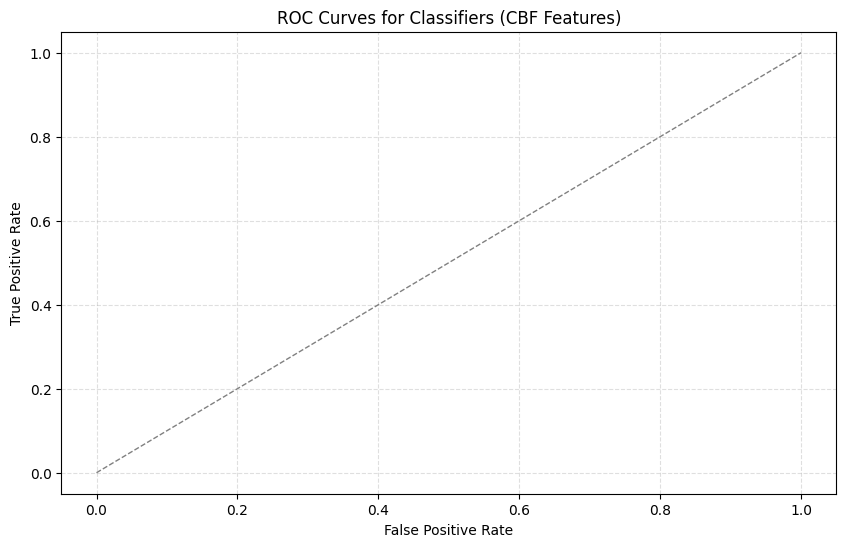

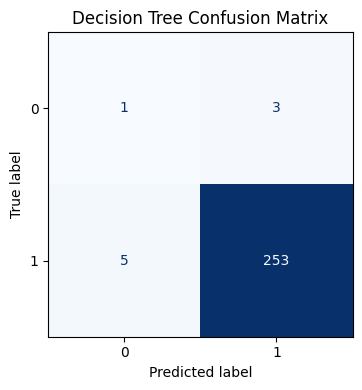

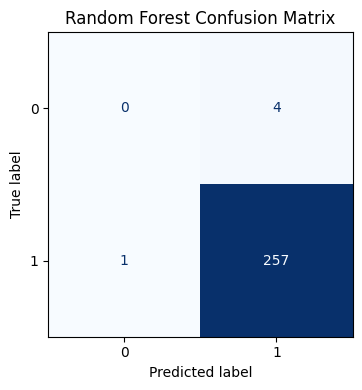

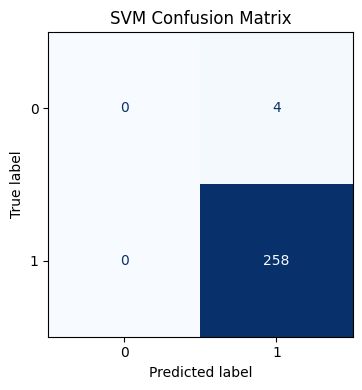

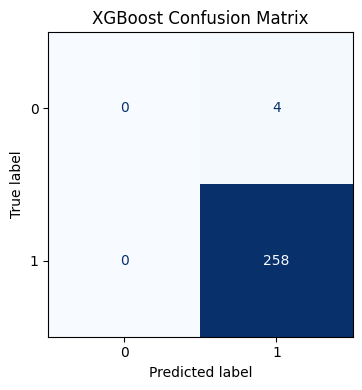

           Model  Accuracy  Precision    Recall        F1  Sensitivity  Specificity
0  Decision Tree  0.969466   0.988281  0.980620  0.984436     0.980620         0.25
1  Random Forest  0.980916   0.984674  0.996124  0.990366     0.996124         0.00
2            SVM  0.984733   0.984733  1.000000  0.992308     1.000000         0.00
3        XGBoost  0.984733   0.984733  1.000000  0.992308     1.000000         0.00


In [ ]:
# =============================================================================
# FINAL RESULTS SUMMARY - CBF CLASSIFICATION THRESHOLDS
# =============================================================================
print("=" * 80)
print("CILIA BEAT FREQUENCY CLASSIFICATION THRESHOLDS SUMMARY")
print("=" * 80)

summary_df = video_df.copy()

# Use the available CBF column in the notebook
cbf_col = 'cbf_mean' if 'cbf_mean' in summary_df.columns else 'cbf_hz'
if cbf_col not in summary_df.columns:
    raise KeyError("Expected 'cbf_mean' or 'cbf_hz' in video_df")

# Build a numeric label column from whichever label format is available
if 'label_bin' in summary_df.columns:
    summary_df['label_bin'] = pd.to_numeric(summary_df['label_bin'], errors='coerce')
elif 'label' in summary_df.columns:
    summary_df['label_bin'] = summary_df['label'].astype(str).str.lower().map({
        'healthy': 0,
        'control': 0,
        'pcd': 1
    })
else:
    raise KeyError("Expected 'label' or 'label_bin' in video_df")

summary_df[cbf_col] = pd.to_numeric(summary_df[cbf_col], errors='coerce')
summary_df = summary_df.dropna(subset=[cbf_col, 'label_bin']).copy()

healthy_cbf = summary_df.loc[summary_df['label_bin'] == 0, cbf_col]
pcd_cbf = summary_df.loc[summary_df['label_bin'] == 1, cbf_col]

def format_mean_std(series):
    if len(series) == 0:
        return "N/A"
    return f"{series.mean():.1f} ± {series.std(ddof=0):.1f} Hz"

print("Dataset Statistics:")
print(f"  Healthy cilia (n={len(healthy_cbf)}):  {format_mean_std(healthy_cbf)}")
print(f"  PCD cilia (n={len(pcd_cbf)}):         {format_mean_std(pcd_cbf)}")
print()

# Literature-validated threshold
LIT_CUTOFF = 11.0
healthy_correct = np.mean(healthy_cbf > LIT_CUTOFF) * 100 if len(healthy_cbf) else np.nan
pcd_correct = np.mean(pcd_cbf < LIT_CUTOFF) * 100 if len(pcd_cbf) else np.nan
overall_accuracy = np.mean(
    ((summary_df['label_bin'] == 0) & (summary_df[cbf_col] > LIT_CUTOFF)) |
    ((summary_df['label_bin'] == 1) & (summary_df[cbf_col] < LIT_CUTOFF))
) * 100 if len(summary_df) else np.nan

# Reuse an available ML accuracy from the notebook state
ml_accuracy_pct = np.nan
if 'xgb_accuracy' in globals():
    ml_accuracy_pct = float(xgb_accuracy) * 100
elif 'results_df' in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    if 'Model' in results_df.columns and 'Accuracy' in results_df.columns:
        rf_row = results_df.loc[results_df['Model'].astype(str).str.lower() == 'random forest', 'Accuracy']
        if not rf_row.empty:
            rf_acc = float(rf_row.iloc[0])
            ml_accuracy_pct = rf_acc * 100 if rf_acc <= 1 else rf_acc
        else:
            best_acc = float(results_df['Accuracy'].astype(float).max())
            ml_accuracy_pct = best_acc * 100 if best_acc <= 1 else best_acc
elif 'y_test' in globals() and 'y_pred' in globals():
    ml_accuracy_pct = accuracy_score(y_test, y_pred) * 100

print("Classification Threshold (>11.0 Hz = Normal, <11.0 Hz = PCD):")
print(f"  Healthy above cutoff:  {healthy_correct:.1f}%")
print(f"  PCD below cutoff:      {pcd_correct:.1f}%")
print(f"  Overall accuracy:      {overall_accuracy:.1f}%")
print(f"  ML classifier accuracy:{ml_accuracy_pct:.1f}%" if not np.isnan(ml_accuracy_pct) else "  ML classifier accuracy:N/A")
print()
print("Reference: ATS 2012 Diagnostic Guidelines")
print("=" * 80)

CILIA BEAT FREQUENCY CLASSIFICATION THRESHOLDS SUMMARY
Dataset Statistics:
  Healthy cilia (n=12):  12.9 ± 7.8 Hz
  PCD cilia (n=379):         14.2 ± 2.0 Hz

Classification Threshold (>11.0 Hz = Normal, <11.0 Hz = PCD):
  Healthy above cutoff:  75.0%
  PCD below cutoff:      2.1%
  Overall accuracy:      4.3%
  ML classifier accuracy:91.5%

Reference: ATS 2012 Diagnostic Guidelines
